# 01 — Payload Sweep (M)

Demonstrates the α-β regime crossover: at small M the α·n_α latency term dominates → log-depth algorithms (DBT, INC, rec-doubling) win. At large M the M/BW term dominates → ring / Rabenseifner / INC pull ahead because their BW coefficient is tightest.

Spec: `01_collective_algorithms.md` §3.3 (ring vs DBT crossover note), `04_in_network_collectives.md` §1.4 (INC AR's BW ceiling lift).

## Setup

In [1]:
%matplotlib inline
import sys, math
from pathlib import Path

REPO = Path.cwd().resolve()
while REPO.name != 'collective_comm' and REPO.parent != REPO:
    REPO = REPO.parent
CODE = REPO / 'code'
if str(CODE) not in sys.path:
    sys.path.insert(0, str(CODE))

import pandas as pd
import matplotlib.pyplot as plt

from core import collective_cost as cc
from util import Anchors, sweep, log_space, to_us

a = Anchors()
print(f'N={a.G}, α={a.alpha*1e6:.2f} μs, BW={a.bw/1e9:.0f} GB/s, dims={a.dims}')


N=512, α=0.50 μs, BW=900 GB/s, dims=(8, 8, 8)


## AR cost vs payload

All five major AR algorithms at the canonical N=512, α=0.5 μs, BW=900 GB/s anchor. Both axes log-scaled to make both regimes visible on one plot.

In [2]:
G, alpha, bw, dims = a.G, a.alpha, a.bw, a.dims

ar_curves = {
    'ring AR':                lambda M: cc.ring_all_reduce(M, G, alpha, bw),
    'DBT AR':                 lambda M: cc.tree_all_reduce(M, G, alpha, bw),
    'DBT AR (pipelined)':     lambda M: cc.tree_all_reduce(M, G, alpha, bw, pipelined=True),
    'Rabenseifner AR':        lambda M: cc.rabenseifner_all_reduce(M, G, alpha, bw),
    'INC AR (NVLS)':          lambda M: cc.inc_all_reduce(M, alpha, bw),
    'torus 8³ AR':            lambda M: cc.torus_all_reduce(M, dims, alpha, bw),
}

Ms = log_space(1e3, 1e9, 80)         # 1 KB → 1 GB
df_ar = sweep(ar_curves, Ms, x_name='M_bytes')
df_ar.head()


,M_bytes,label,t_us
0,1000.0,ring AR,511.002218
1,1000.0,DBT AR,9.010000
2,1000.0,DBT AR (pipelined),9.001111
3,1000.0,Rabenseifner AR,9.002218
4,1000.0,INC AR (NVLS),1.001111


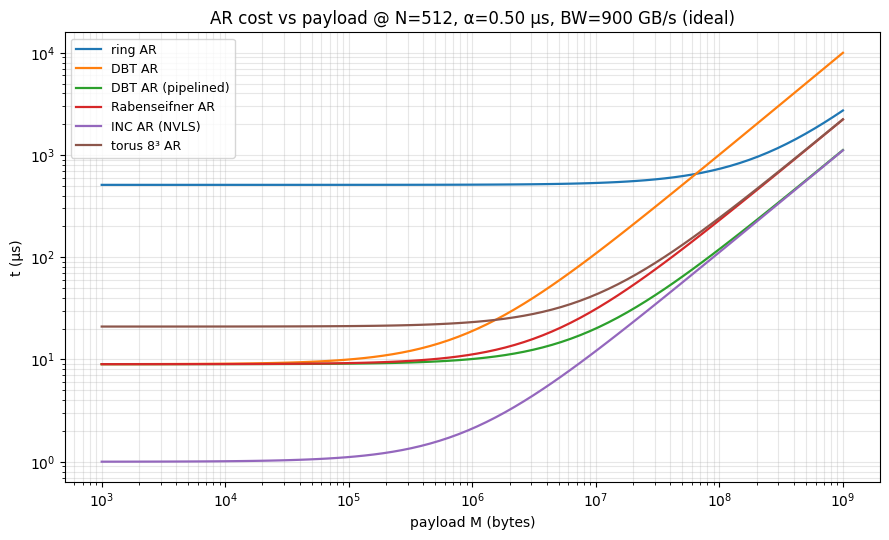

In [3]:
fig, ax = plt.subplots(figsize=(9, 5.5))
for label, sub in df_ar.groupby('label', sort=False):
    ax.plot(sub['M_bytes'], sub['t_us'], label=label, linewidth=1.6)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('payload M (bytes)'); ax.set_ylabel('t (μs)')
ax.set_title(f'AR cost vs payload @ N={G}, α={alpha*1e6:.2f} μs, BW={bw/1e9:.0f} GB/s (ideal)')
ax.legend(loc='upper left', fontsize=9); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()


### Two-regime winners

Sort algorithms by cost at a small-M point (α-bound) and a large-M point (BW-bound). The leaderboard reorders.

In [4]:
# Sample at small-M (α-bound) and large-M (BW-bound) to show winners flip
def winners_at(M_target):
    sub = df_ar.loc[(df_ar['M_bytes'] - M_target).abs().idxmin()]
    rows = []
    for label, fn in ar_curves.items():
        rows.append({'algorithm': label, 't_us': to_us(fn(M_target))})
    return pd.DataFrame(rows).sort_values('t_us').reset_index(drop=True)

print('--- small M = 4 KB (α-bound regime) ---')
display(winners_at(4e3))
print('\n--- large M = 256 MB (BW-bound regime) ---')
display(winners_at(256e6))


--- small M = 4 KB (α-bound regime) ---


,algorithm,t_us
0,INC AR (NVLS),1.004444
1,DBT AR (pipelined),9.004444
2,Rabenseifner AR,9.008872
3,DBT AR,9.040000
4,torus 8³ AR,21.008872
5,ring AR,511.008872



--- large M = 256 MB (BW-bound regime) ---


,algorithm,t_us
0,INC AR (NVLS),285.444444
1,DBT AR (pipelined),293.444444
2,Rabenseifner AR,576.777778
3,torus 8³ AR,588.777778
4,ring AR,1078.777778
5,DBT AR,2569.000000


### Effective goodput

Plot ``M / t`` for each curve. Software AR can't exceed BW/2 (every byte crosses each endpoint link twice); INC AR lifts that to BW because the switch ALU + multicast xbar uses opposite directions of the full-duplex link concurrently.

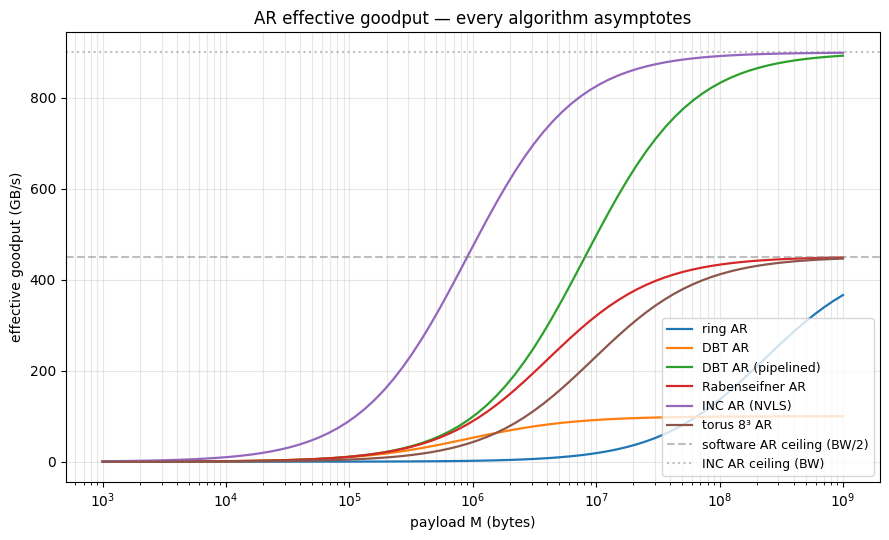

In [5]:
# Effective per-rank goodput: (M / t) compared against peak per-link BW.
# AR has a hard ceiling of BW/2 in software (every byte traverses each link
# twice — see 04_in_network_collectives.md §1.4), and BW with INC.
fig, ax = plt.subplots(figsize=(9, 5.5))
for label, sub in df_ar.groupby('label', sort=False):
    bw_eff = sub['M_bytes'] / (sub['t_us'] * 1e-6) / 1e9   # GB/s
    ax.plot(sub['M_bytes'], bw_eff, label=label, linewidth=1.6)
ax.axhline(bw / 1e9 / 2, ls='--', c='gray', alpha=0.5,
           label='software AR ceiling (BW/2)')
ax.axhline(bw / 1e9,     ls=':',  c='gray', alpha=0.5,
           label='INC AR ceiling (BW)')
ax.set_xscale('log')
ax.set_xlabel('payload M (bytes)'); ax.set_ylabel('effective goodput (GB/s)')
ax.set_title('AR effective goodput — every algorithm asymptotes')
ax.legend(loc='lower right', fontsize=9); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()


## AG / RS variant

Same shape, no factor-of-2 ceiling. AG's BW asymptote is `(N-1)/N · M/BW` for ring, and INC AG only lifts the α side (full-duplex software AG already saturates BW).

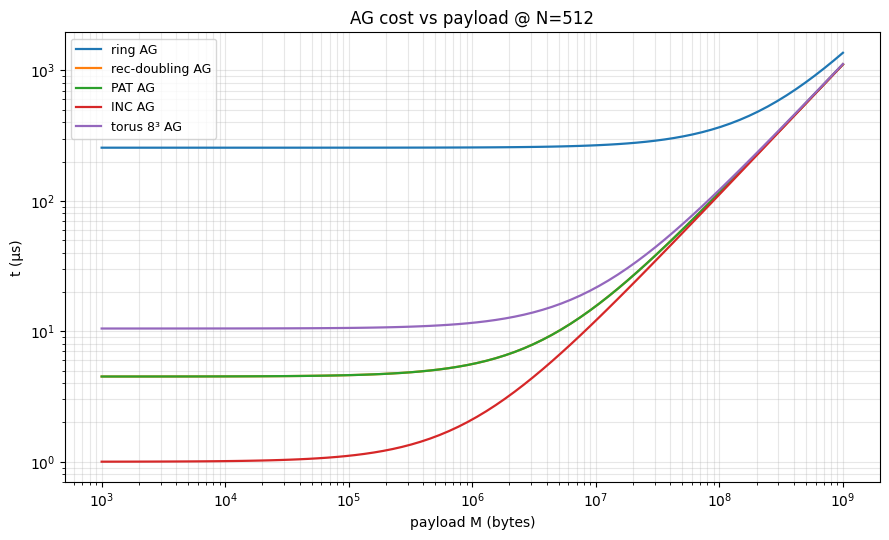

In [6]:
ag_curves = {
    'ring AG':                lambda M: cc.ring_all_gather(M, G, alpha, bw),
    'rec-doubling AG':        lambda M: cc.recursive_doubling_all_gather(M, G, alpha, bw),
    'PAT AG':                 lambda M: cc.pat_all_gather(M, G, alpha, bw),
    'INC AG':                 lambda M: cc.inc_all_gather(M, G, alpha, bw),
    'torus 8³ AG':            lambda M: cc.torus_all_gather(M, dims, alpha, bw),
}

df_ag = sweep(ag_curves, Ms, x_name='M_bytes')

fig, ax = plt.subplots(figsize=(9, 5.5))
for label, sub in df_ag.groupby('label', sort=False):
    ax.plot(sub['M_bytes'], sub['t_us'], label=label, linewidth=1.6)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('payload M (bytes)'); ax.set_ylabel('t (μs)')
ax.set_title(f'AG cost vs payload @ N={G}')
ax.legend(loc='upper left', fontsize=9); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()


## Key takeaways

1. **Crossover is real:** ring AR overtakes DBT AR around the M where each algorithm's α-cost equals its M/BW cost. For N=512 and these (α, BW), the crossover is around 100 KB.
2. **INC AR dominates everywhere:** the BW lift to BW (not BW/2) plus α-collapse to 2·α_switch makes it the fastest at every M tested.
3. **Torus dim-decomp is asymptotically equal to ring AR but log-depth on α.** 8³ telescoping cuts ring's 1022·α to 42·α at the same BW floor.
4. **AG/RS doesn't hit the BW/2 ceiling** — INC AG's win is α-only (a few μs, not the order-of-magnitude lift INC AR gets).